# Tugas 2 Analisis Data Time Series

Nama: (isi nama)
NIM: (isi NIM)
Kelas: (isi kelas)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

# Load data Tugas 1
df = pd.read_csv('data_BBCA_bulanan.csv')
df['Bulan'] = pd.to_datetime(df['Bulan'])
df.set_index('Bulan', inplace=True)
df = df.asfreq('MS')  # frekuensi bulanan (Month Start)

y = df['Harga_Penutupan']
df.head()

,Harga_Penutupan
Bulan,
2023-01-01,8475.0
2023-02-01,8750.0
2023-03-01,8750.0
2023-04-01,9050.0
2023-05-01,9050.0


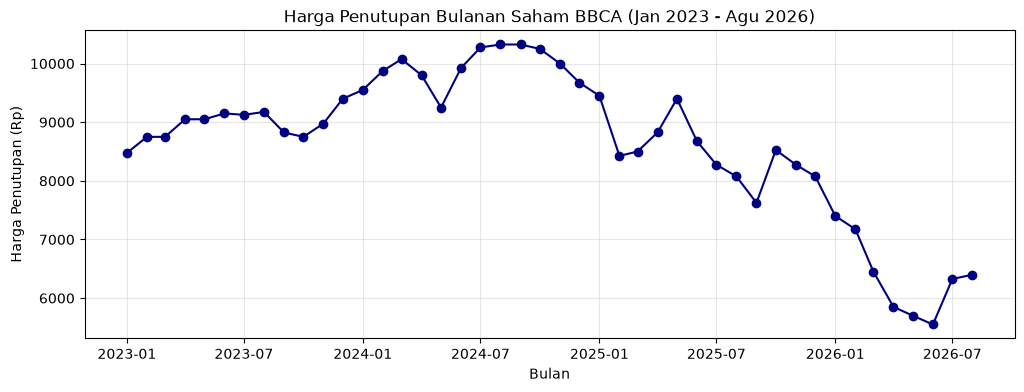

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(y, marker='o', color='navy')
plt.title('Harga Penutupan Bulanan Saham BBCA (Jan 2023 - Agu 2026)')
plt.xlabel('Bulan')
plt.ylabel('Harga Penutupan (Rp)')
plt.grid(True, alpha=0.3)
plt.show()

## 1. White Noise

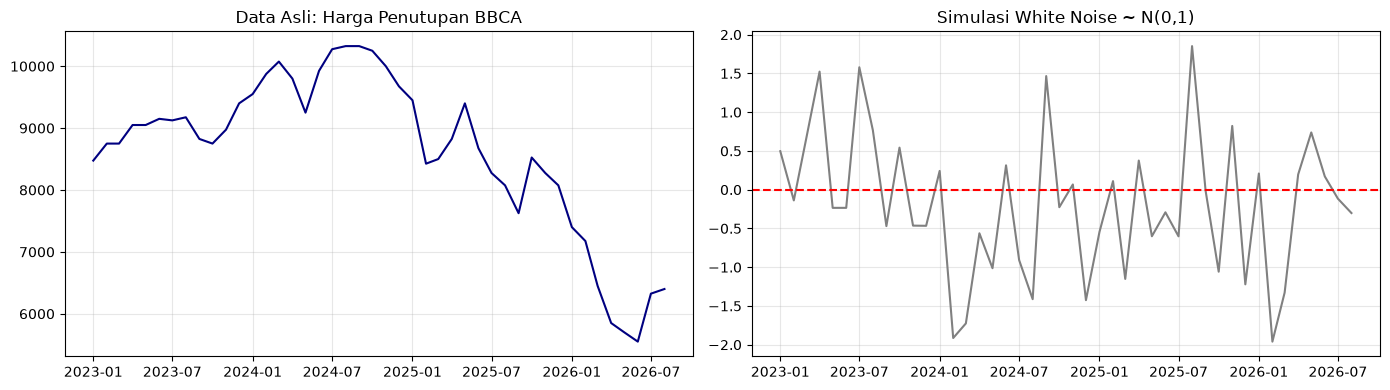

In [4]:
np.random.seed(42)
white_noise_sim = np.random.normal(loc=0, scale=1, size=len(y))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, y.values, color='navy')
axes[0].set_title('Data Asli: Harga Penutupan BBCA')
axes[0].grid(True, alpha=0.3)

axes[1].plot(y.index, white_noise_sim, color='gray')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Simulasi White Noise ~ N(0,1)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Uji formal: Ljung-Box Test
# H0: Data adalah white noise (tidak ada autokorelasi)
# H1: Data bukan white noise (ada autokorelasi)
lb_level = acorr_ljungbox(y, lags=[6, 12], return_df=True)
print("Uji Ljung-Box pada data asli (level):")
print(lb_level)

Uji Ljung-Box pada data asli (level):
       lb_stat     lb_pvalue
6   129.663785  1.512898e-25
12  143.393663  1.235100e-24


## 2. Random Walk

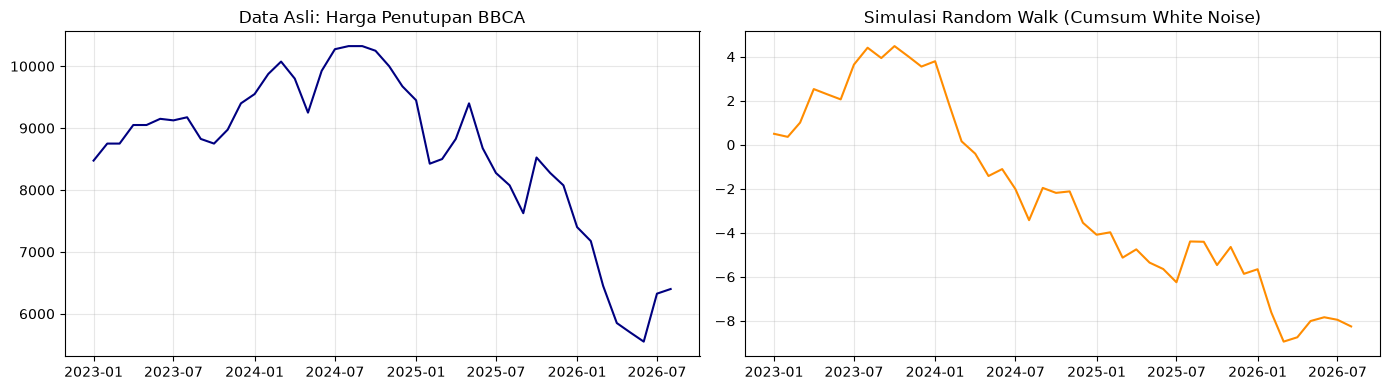

In [6]:
np.random.seed(42)
n = len(y)
wn = np.random.normal(0, 1, n)
random_walk_sim = np.cumsum(wn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y.index, y.values, color='navy')
axes[0].set_title('Data Asli: Harga Penutupan BBCA')
axes[0].grid(True, alpha=0.3)

axes[1].plot(y.index, random_walk_sim, color='darkorange')
axes[1].set_title('Simulasi Random Walk (Cumsum White Noise)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

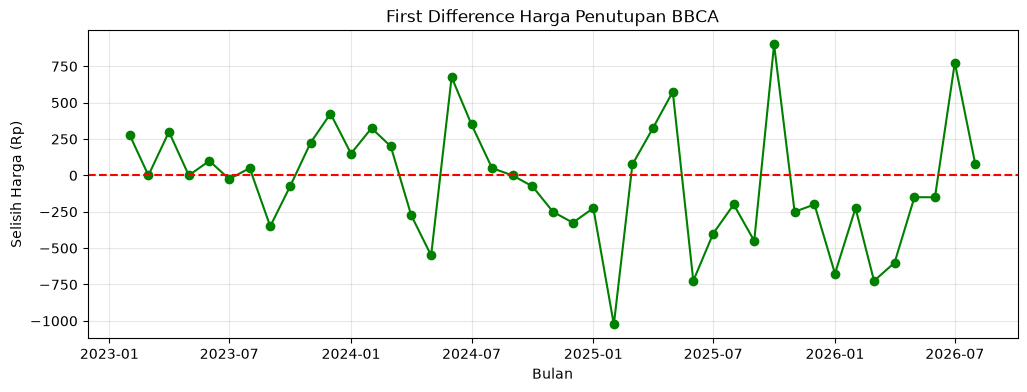

Uji Ljung-Box pada first difference:
      lb_stat  lb_pvalue
6    3.235971   0.778700
12  14.573828   0.265574


In [7]:
# First difference dari data asli
diff1 = y.diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(diff1, color='green', marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('First Difference Harga Penutupan BBCA')
plt.xlabel('Bulan')
plt.ylabel('Selisih Harga (Rp)')
plt.grid(True, alpha=0.3)
plt.show()

lb_diff1 = acorr_ljungbox(diff1, lags=[6, 12], return_df=True)
print("Uji Ljung-Box pada first difference:")
print(lb_diff1)

## 3. ACF dan PACF

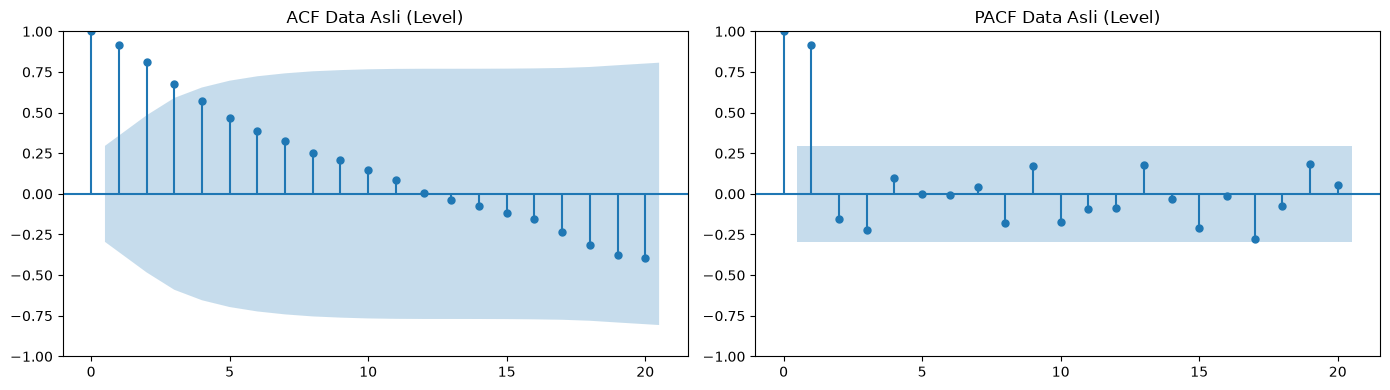

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title('ACF Data Asli (Level)')
plot_pacf(y, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('PACF Data Asli (Level)')
plt.tight_layout()
plt.show()

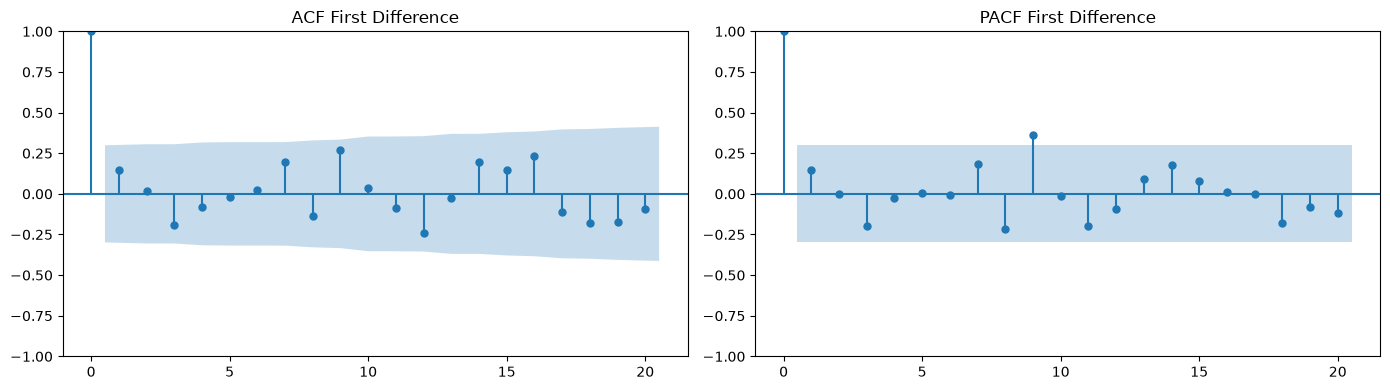

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1, lags=20, ax=axes[0])
axes[0].set_title('ACF First Difference')
plot_pacf(diff1, lags=20, ax=axes[1], method='ywm')
axes[1].set_title('PACF First Difference')
plt.tight_layout()
plt.show()

## 4. Dekomposisi

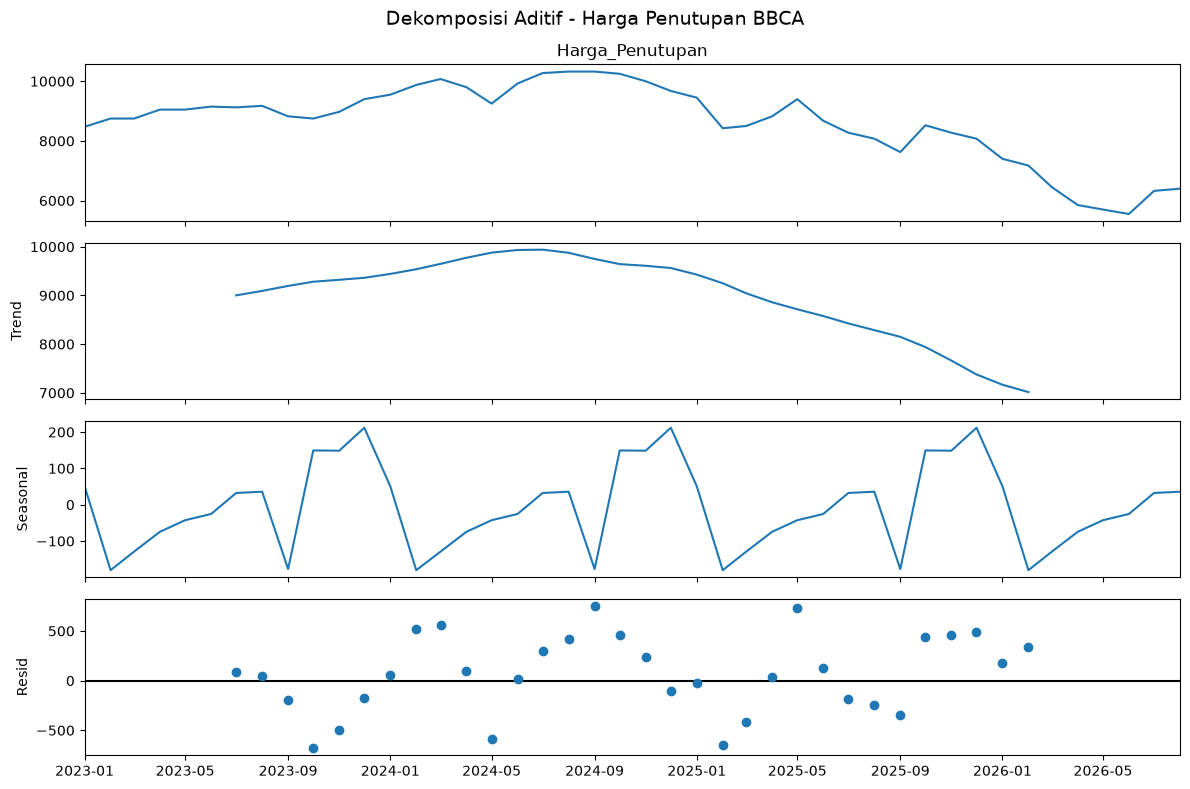

In [10]:
decomp_add = seasonal_decompose(y, model='additive', period=12)
fig = decomp_add.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Aditif - Harga Penutupan BBCA', fontsize=14)
plt.tight_layout()
plt.show()

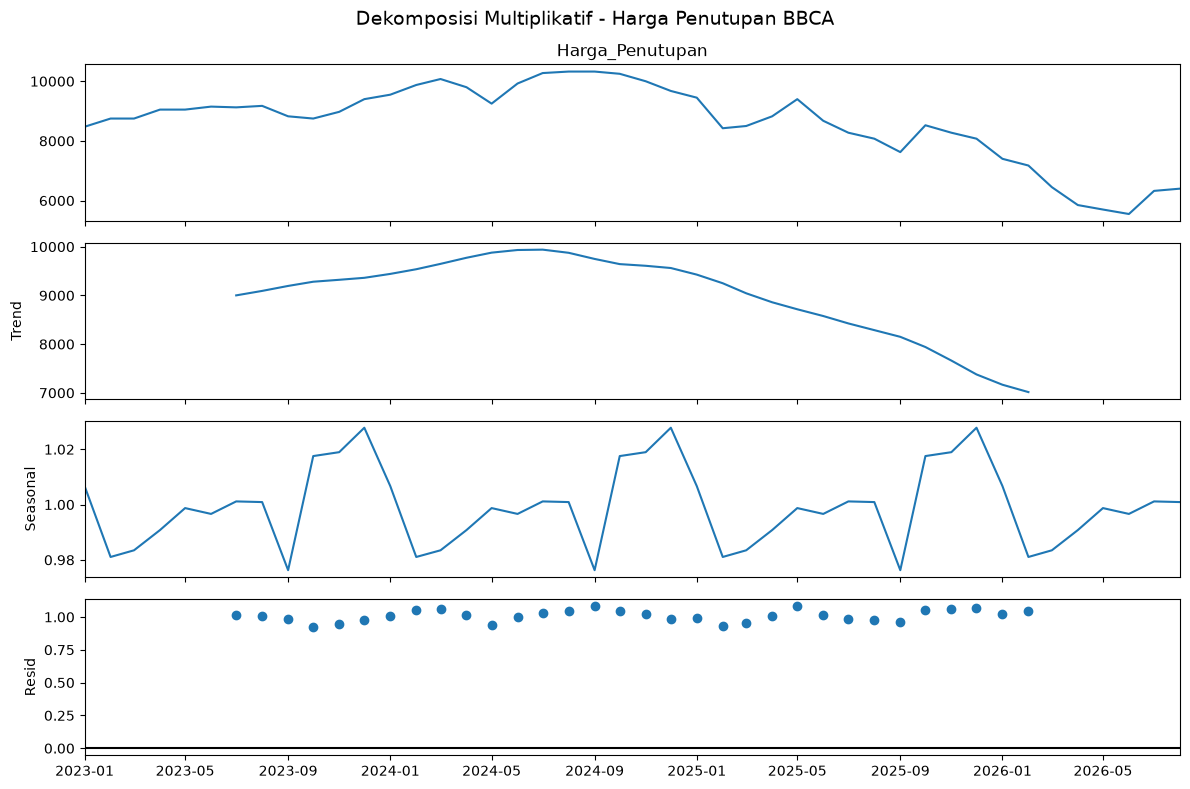

In [11]:
decomp_mul = seasonal_decompose(y, model='multiplicative', period=12)
fig = decomp_mul.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi Multiplikatif - Harga Penutupan BBCA', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print("Varians residual model Aditif       :", np.nanvar(decomp_add.resid))
print("Varians residual model Multiplikatif :", np.nanvar(decomp_mul.resid))

Varians residual model Aditif       : 150204.34344256367
Varians residual model Multiplikatif : 0.0018983605174238108


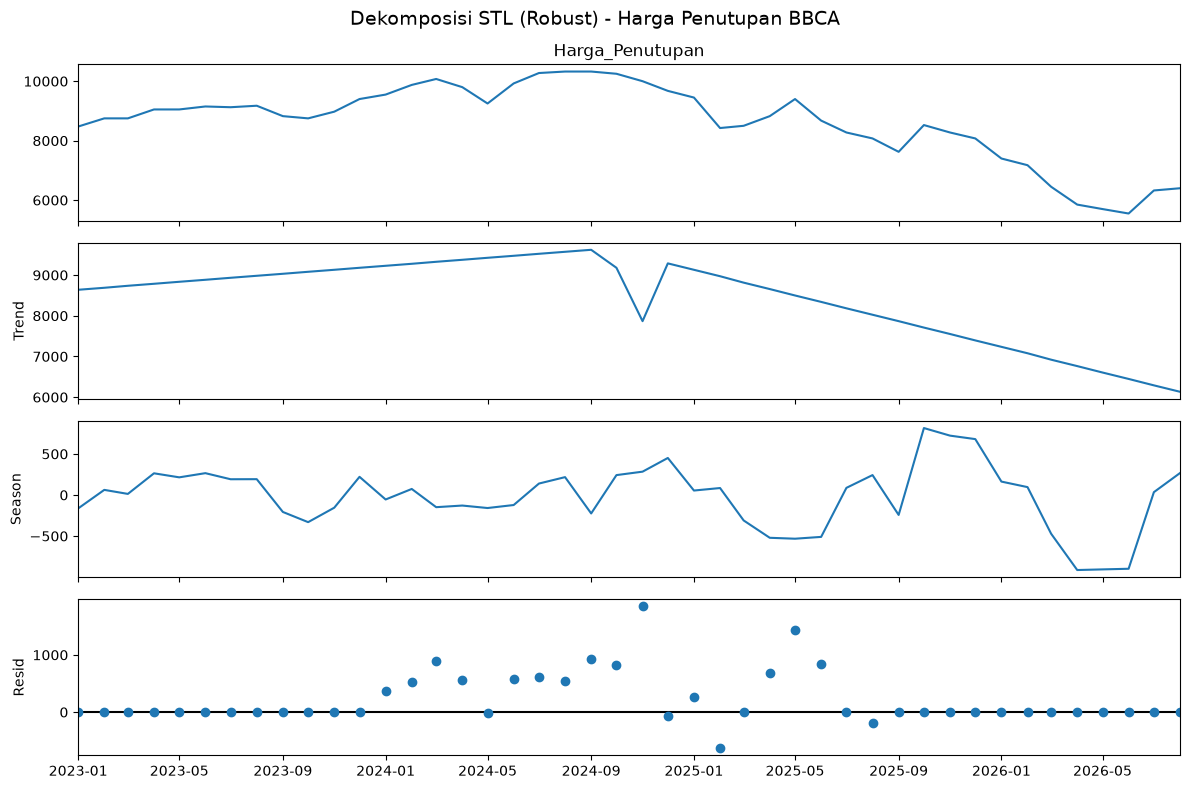

In [13]:
stl = STL(y, period=12, robust=True)
res_stl = stl.fit()
fig = res_stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Dekomposisi STL (Robust) - Harga Penutupan BBCA', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Uji Stasioneritas dan Differencing

In [14]:
def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"--- ADF Test: {label} ---")
    print(f"Statistik ADF : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Kesimpulan    : {'STASIONER (tolak H0)' if result[1] < 0.05 else 'TIDAK STASIONER (gagal tolak H0)'}")
    print()
    return result[1]

def kpss_test(series, label):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"--- KPSS Test: {label} ---")
    print(f"Statistik KPSS: {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Kesimpulan    : {'STASIONER (gagal tolak H0)' if result[1] > 0.05 else 'TIDAK STASIONER (tolak H0)'}")
    print()
    return result[1]

print("======== DATA ASLI (LEVEL) ========")
adf_test(y, "Level")
kpss_test(y, "Level")

======== DATA ASLI (LEVEL) ========
--- ADF Test: Level ---
Statistik ADF : -0.3076
p-value       : 0.9244
Kesimpulan    : TIDAK STASIONER (gagal tolak H0)

--- KPSS Test: Level ---
Statistik KPSS: 0.5850
p-value       : 0.0240
Kesimpulan    : TIDAK STASIONER (tolak H0)



/var/folders/jy/2v539_dx5tv6trrm_mg5m1qc0000gn/T/ipykernel_4886/1490619488.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/var/folders/jy/2v539_dx5tv6trrm_mg5m1qc0000gn/T/ipykernel_4886/1490619488.py:11: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = kpss(series.dropna(),

np.float64(0.023995969091795112)

======== FIRST DIFFERENCE (d=1) ========
--- ADF Test: Diff-1 ---
Statistik ADF : -5.4828
p-value       : 0.0000
Kesimpulan    : STASIONER (tolak H0)

--- KPSS Test: Diff-1 ---
Statistik KPSS: 0.2971
p-value       : 0.1000
Kesimpulan    : STASIONER (gagal tolak H0)



/var/folders/jy/2v539_dx5tv6trrm_mg5m1qc0000gn/T/ipykernel_4886/1490619488.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
/var/folders/jy/2v539_dx5tv6trrm_mg5m1qc0000gn/T/ipykernel_4886/1490619488.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  result = kpss(series.dropna(), regression='c', nlags='auto')
/var/folders/jy/2v539_dx5tv6trrm_mg5m1qc0000gn/T/ipykernel_4886/1490619488.py:11: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which 

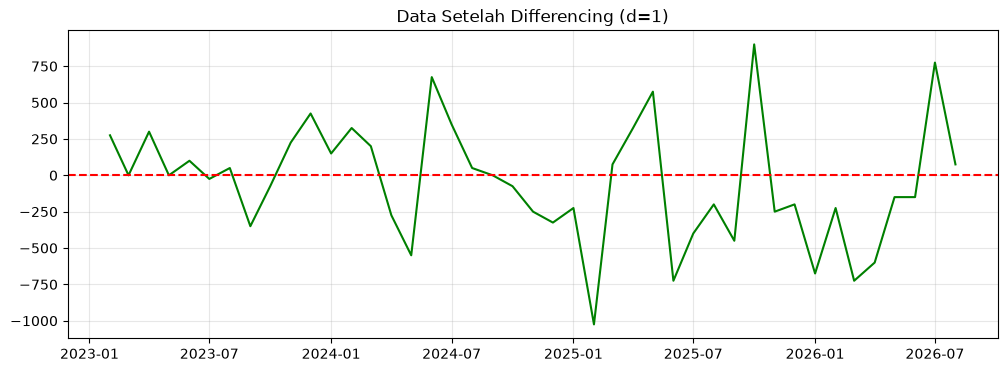

In [15]:
print("======== FIRST DIFFERENCE (d=1) ========")
adf_test(diff1, "Diff-1")
kpss_test(diff1, "Diff-1")

plt.figure(figsize=(12, 4))
plt.plot(diff1, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title('Data Setelah Differencing (d=1)')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Invertibilitas

In [16]:
model = ARIMA(y, order=(0, 1, 1))
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:        Harga_Penutupan   No. Observations:                   44
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -319.093
Date:                Tue, 01 Sep 2026   AIC                            642.186
Time:                        11:24:32   BIC                            645.708
Sample:                    01-01-2023   HQIC                           643.485
                         - 08-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1582      0.176      0.897      0.370      -0.188       0.504
sigma2       1.64e+05   3.54e+04      4.631      0.000    9.46e+04    2.33e+05
Ljung-Box (L1) (Q):                   0.01   Jarque-

In [17]:
ma_coef = res.params['ma.L1']
print(f"Koefisien MA(1) hasil estimasi dari data BBCA: {ma_coef:.4f}")

# Dalam konvensi statsmodels, polinomial MA ditulis (1 + theta*B) dengan tanda positif
ma_params_fitted = np.array([1, ma_coef])
ar_params = np.array([1])  # tidak ada komponen AR

process_fitted = ArmaProcess(ar_params, ma_params_fitted)
print(f"Apakah model MA(1) hasil fit terhadap data BBCA invertibel? {process_fitted.isinvertible}")
print(f"Akar polinomial MA: {process_fitted.maroots}")

Koefisien MA(1) hasil estimasi dari data BBCA: 0.1582
Apakah model MA(1) hasil fit terhadap data BBCA invertibel? True
Akar polinomial MA: [-6.32235188]


In [18]:
# Sebagai pembanding (mengikuti contoh dosen): kasus non-invertibel
ma_params_noninvertible = np.array([1, 2.0])  # theta = -2.0, |theta| > 1
process_noninv = ArmaProcess(ar_params, ma_params_noninvertible)

print(f"Contoh MA(1) dengan theta = -2.0 -> invertibel? {process_noninv.isinvertible}")
print(f"Akar polinomial MA: {process_noninv.maroots}")

Contoh MA(1) dengan theta = -2.0 -> invertibel? False
Akar polinomial MA: [-0.5]
